# **Training a CNN: Hyperparameter Optimization with PyTorch**

**Aim:** separate parameters from hyperparameters, study the learning rate, schedules and batch size numerically, compare grid / random / Bayesian / successive-halving search, and finish with a real random search under successive halving on CIFAR-10.



# **Step 0 — Setup**


In [1]:
import math                      # log, ceil, floor, cos and pi for the formulas
import random                    # Python RNG used to sample hyperparameter configurations in Part 8
import functools, operator       # product of the candidate counts (size of a grid) in Part 5
import torch                     # tensor library + autograd
import torch.nn as nn            # layers and the loss function
import torch.nn.functional as F  # relu etc. used inside the CNN
import torchvision               # CIFAR-10 dataset (used only in Part 8)
import torchvision.transforms as transforms   # image -> tensor, normalisation
import matplotlib.pyplot as plt  # for the plots

# Make results repeatable - same reason as in Practical 9.
torch.manual_seed(0)

# Use the GPU if Colab gives us one, otherwise the CPU (everything here also runs on CPU).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch", torch.__version__, "│ device:", device)

PyTorch 2.11.0+cu130 │ device: cuda


## Checkpoint

### Q1. Why pick `device = cuda` if available?
Convolutions and matrix products run much faster on a GPU, and the same code runs unchanged on the CPU. Only Part 8 trains real networks, so only Part 8 benefits.

### Q2. Why call `torch.manual_seed(0)`?
Fixes the random number generator so results are repeatable and a change in output can be traced to your edit, not to luck.


# **Part 1 — Parameters and Hyperparameters**  *(Experiment 1)*

**Aim:** show in a live PyTorch model that the two kinds of quantity are separated by the training loop.

A **trainable parameter** is anything the optimizer updates by backpropagation: the weights and biases collected in `model.parameters()`. A **hyperparameter** is anything fixed *before* training starts: learning rate, batch size, optimizer, weight decay, dropout probability, number of epochs. Hyperparameters live in our own configuration, not in the model.

Choosing them is a **nested problem**. For a configuration $\lambda$ the inner problem trains the network, and the outer problem picks the configuration whose trained network scores best on validation data:

$$w^*(\lambda) = \arg\min_w J_{train}(w;\lambda) \qquad\qquad \lambda^* = \arg\min_\lambda J_{val}\big(w^*(\lambda);\lambda\big)$$

One evaluation of the outer objective means training a whole network, and it has no usable gradient with respect to $\lambda$, so gradient descent cannot minimise it. Every method below is a way of searching it cheaply. The small CNN defined here (three conv blocks, two FC layers) returns in Part 8.


In [2]:
class SmallCNN(nn.Module):
    """A small CNN: three conv blocks, then two FC layers."""
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)     # 3 colour channels -> 32 feature maps
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)                  # halves height and width
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.drop  = nn.Dropout(dropout)                 # a layer, but it has NO weights
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))    # 16x16 -> 8x8
        x = self.pool(F.relu(self.conv3(x)))    # 8x8   -> 4x4
        x = torch.flatten(x, 1)
        return self.fc2(self.drop(F.relu(self.fc1(x))))

# The hyperparameters live in OUR configuration, not in the model.
config = {"learning_rate": 1e-3, "batch_size": 128, "optimizer": "adam",
          "weight_decay": 1e-4, "dropout": 0.5, "epochs": 20}

model = SmallCNN(dropout=config["dropout"])

print("trainable tensors :", len(list(model.parameters())))
print("trainable scalars :", f"{sum(p.numel() for p in model.parameters()):,}")
print("hyperparameters   :", len(config), "->", list(config))

# Check the dividing line: no config key is a parameter name, and the dropout layer owns no weights.
names = [n for n, _ in model.named_parameters()]
print("\nparameter names   :", names)
print("names shared with config :", set(names) & set(config))
print("scalars inside nn.Dropout:", sum(p.numel() for p in model.drop.parameters()))
print("output shape for 2 images:", tuple(model(torch.randn(2, 3, 32, 32)).shape))

trainable tensors : 10
trainable scalars : 620,362
hyperparameters   : 6 -> ['learning_rate', 'batch_size', 'optimizer', 'weight_decay', 'dropout', 'epochs']

parameter names   : ['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv3.weight', 'conv3.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']
names shared with config : set()
scalars inside nn.Dropout: 0
output shape for 2 images: (2, 10)


**Result:** matches the manual — **10** trainable tensors, **620,362** trainable scalars, **6** hyperparameters. By hand: conv1 = 3·32·9 + 32 = 896; conv2 = 32·64·9 + 64 = 18,496; conv3 = 64·128·9 + 128 = 73,856; fc1 = 2048·256 + 256 = 524,544; fc2 = 256·10 + 10 = 2,570; total 896 + 18,496 + 73,856 + 524,544 + 2,570 = **620,362** ✅.

No name in `config` is a parameter name, and `nn.Dropout` owns **0** scalars. Dropout appears on both sides of the line: the number 0.5 is a hyperparameter we *chose* (in `config`), the layer is just the machinery that applies it.


## Checkpoint

### Q1. Trainable parameter vs hyperparameter?
Parameters (weights, biases) are learned by gradient descent; backpropagation reaches exactly the 620,362 scalars of `model.parameters()`. Hyperparameters (lr, batch size, optimizer, weight decay, dropout, epochs) are chosen by us before training and stored in `config`.

### Q2. Write the nested HPO problem.
Inner: $w^*(\lambda)=\arg\min_w J_{train}(w;\lambda)$. Outer: $\lambda^*=\arg\min_\lambda J_{val}(w^*(\lambda);\lambda)$.

### Q3. Why can't gradient descent minimise the outer objective?
One evaluation needs a full training run, and there is no usable gradient of the validation loss with respect to λ (batch size, optimizer, epochs are discrete; even continuous ones act through a whole training run).

### Q4. Which of the two does `nn.Dropout(0.5)` belong to?
Both: 0.5 is a hyperparameter (a choice, made by search); the layer itself has no weights, so nothing in it is trained.


# **Part 2 — The Learning-Rate Stability Window**  *(Experiment 2)*

**Aim:** verify, by simulation and by formula, that only a bounded window of learning rates converges.

Take the simplest loss, a 1-D quadratic $J(w)=\tfrac12 a w^2$ with curvature $a>0$ and minimum at $w=0$. Its gradient is $aw$, so one gradient-descent step with learning rate $\eta$ gives

$$w_{t+1} = w_t - \eta a\, w_t = (1-\eta a)\,w_t \quad\Rightarrow\quad w_t = (1-\eta a)^t\, w_0$$

The iterates shrink to zero exactly when $|1-\eta a|<1$:

$$0<\eta<\frac{2}{a}, \qquad \eta_{opt}=\frac1a$$

For $1/a<\eta<2/a$ the iterates still converge but **alternate in sign**; at $\eta=2/a$ they bounce between $\pm w_0$ forever; above it they diverge. In a real network $a$ plays the role of the largest curvature of the loss. With $a=4$: window $0<\eta<0.5$, best rate $0.25$.


In [3]:
a, w0 = 4.0, 1.0                                   # curvature a = 4, start at w0 = 1
print("stability range : 0 < eta <", 2 / a)
print("fastest rate    : eta =", 1 / a)

def gradient_descent(a, w0, eta, steps):
    """The recursion w <- w(1 - eta*a), repeated."""
    w, history = w0, [w0]
    for _ in range(steps):
        w = w - eta * (a * w)                          # gradient of J(w) = a*w^2/2 is a*w
        history.append(w)
    return history

for eta in [0.02, 0.2, 0.25, 0.45, 0.5, 0.6]:
    h = gradient_descent(a, w0, eta, 30)
    factor = abs(1 - eta * a)
    print(f"eta={eta:<5}  │1 - eta*a│ = {factor:.3f}   w_30 = {h[-1]:+.3e}")

stability range : 0 < eta < 0.5
fastest rate    : eta = 0.25
eta=0.02   │1 - eta*a│ = 0.920   w_30 = +8.197e-02
eta=0.2    │1 - eta*a│ = 0.200   w_30 = +1.074e-21
eta=0.25   │1 - eta*a│ = 0.000   w_30 = +0.000e+00
eta=0.45   │1 - eta*a│ = 0.800   w_30 = +1.238e-03
eta=0.5    │1 - eta*a│ = 1.000   w_30 = +1.000e+00
eta=0.6    │1 - eta*a│ = 1.400   w_30 = +2.420e+04


**Result:** matches the manual. All four regimes appear, each readable from $|1-\eta a|$ alone:

| η | \|1 − ηa\| | behaviour |
|---|---|---|
| 0.02 | 0.92 | converges, slowly (w₃₀ = 8.2e-2) |
| 0.2 | 0.20 | converges fast (w₃₀ ≈ 1e-21) |
| 0.25 | 0.00 | minimum in **one** step (η = 1/a) |
| 0.45 | 0.80 | converges with alternating sign (w₃₀ = 1.2e-3) |
| 0.5 | 1.00 | never shrinks — bounces between ±1 (w₃₀ = +1) |
| 0.6 | 1.40 | **diverges** (w₃₀ = 2.4e+04) |


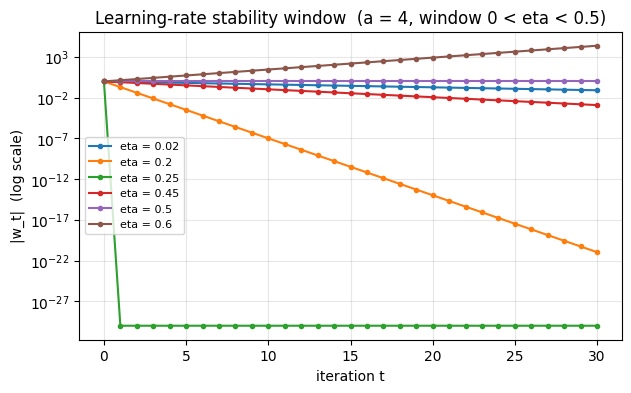

In [4]:
# Plot |w_t| on a log axis: a straight falling line = geometric convergence, a rising line = divergence.
# (eta = 0.25 reaches exactly 0 in one step, so it is drawn at the 1e-30 floor.)
plt.figure(figsize=(7, 4))
for eta in [0.02, 0.2, 0.25, 0.45, 0.5, 0.6]:
    h = gradient_descent(a, w0, eta, 30)
    plt.semilogy([abs(v) + 1e-30 for v in h], marker="o", markersize=3, label=f"eta = {eta}")
plt.xlabel("iteration t")
plt.ylabel("|w_t|  (log scale)")
plt.title("Learning-rate stability window  (a = 4, window 0 < eta < 0.5)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

How many iterations before $|w_t|\le\varepsilon$? Take logarithms of $|1-\eta a|^t|w_0|\le\varepsilon$ (the log in the denominator is negative, which flips the inequality):

$$t \;\ge\; \frac{\ln(\varepsilon/|w_0|)}{\ln|1-\eta a|}$$

With $\varepsilon=0.01$ the formula predicts 56 iterations at $\eta=0.02$ and 3 at $\eta=0.2$. Compute both from the formula and from the simulation and check that they agree.


In [5]:
def iterations_needed(eps, a, w0, eta):
    """Smallest t with |1 - eta*a|^t * |w0| <= eps."""
    factor = abs(1 - eta * a)
    if factor >= 1:
        return None                                    # never converges
    return math.ceil(math.log(eps / w0) / math.log(factor))

for eta in [0.02, 0.2]:
    predicted = iterations_needed(0.01, a, w0, eta)    # from the formula
    h = gradient_descent(a, w0, eta, 200)
    observed = next(k for k, w in enumerate(h) if abs(w) <= 0.01)   # from the simulation
    print(f"eta={eta}:  formula {predicted} iterations,  simulation {observed}")

eta=0.02:  formula 56 iterations,  simulation 56
eta=0.2:  formula 3 iterations,  simulation 3


**Result:** formula and simulation agree exactly (56 and 3). By hand: ln(0.01)/ln(0.92) = −4.605/−0.0834 = 55.2 → **56**; ln(0.01)/ln(0.2) = 2.86 → **3** ✅. The tenfold change from η = 0.02 to η = 0.2 cuts training from 56 iterations to 3 without touching the model — a factor of ≈ 19. That is why the learning rate is searched first and on a **logarithmic** scale.


## Tasks

### Exercise 1 — Add η = 0.5 exactly and η = 0.49, run 200 steps
Describe the two behaviours and relate them to the boundary of the stability window.


In [ ]:
# Exercise 1: add eta = 0.5 exactly and eta = 0.49, run 200 steps.
for eta in [0.49, 0.5]:
    h = gradient_descent(a, w0, eta, 200)
    print(f"eta={eta}:  factor 1 - eta*a = {1 - eta * a:+.2f}   |factor| = {abs(1 - eta * a):.2f}")
    print(f"    first iterates : {[round(v, 4) for v in h[:6]]}")
    print(f"    w_200          : {h[-1]:+.4e}      iterations to |w| <= 0.01 : {iterations_needed(0.01, a, w0, eta)}")

eta=0.49:  factor 1 - eta*a = -0.96   |factor| = 0.96
    first iterates : [1.0, -0.96, 0.9216, -0.8847, 0.8493, -0.8154]
    w_200          : +2.8461e-04      iterations to |w| <= 0.01 : 113
eta=0.5:  factor 1 - eta*a = -1.00   |factor| = 1.00
    first iterates : [1.0, -1.0, 1.0, -1.0, 1.0, -1.0]
    w_200          : +1.0000e+00      iterations to |w| <= 0.01 : None


**Result:**

- **η = 0.5** (exactly on the boundary, 2/a): the factor is $1-0.5\cdot4=-1$, so $w\leftarrow -w$. The iterates are $1,-1,1,-1,\dots$ forever; $|w|$ never shrinks, and $w_{200}=+1$ only because 200 is even. It never reaches $|w|\le0.01$.
- **η = 0.49** (just inside): the factor is $-0.96$, so the iterates alternate in sign **and** shrink by 4% per step. $w_{200}=(-0.96)^{200}=2.85\times10^{-4}$, and $|w|\le0.01$ is reached after $\ln(0.01)/\ln(0.96)\approx$ **113** iterations.

Moving η by 0.01 across the boundary turns "converges in ~113 steps" into "never converges": the window edge at 2/a is sharp, not gradual.


### Exercise 2 — Change a from 4 to 100
Recompute the stability range and the fastest rate. What does this suggest about a loss with one very large curvature?

To see the consequence, the cell adds a second, **flat** direction with curvature 1 that must share the same learning rate.


In [6]:
# Exercise 2: a = 100 instead of 4.
a2 = 100.0
print("a = 100:  stability range 0 < eta <", 2 / a2, "  fastest rate eta =", 1 / a2)

# One steep direction (a = 100) and one flat direction (a = 1) share ONE learning rate.
print(f"\n{'eta':>6}{'steep a=100: |factor|':>24}{'flat a=1: |factor|':>22}{'flat: iters to 0.01':>22}")
for eta in [0.005, 0.01, 0.019, 0.02, 0.025]:
    f_steep, f_flat = abs(1 - eta * 100), abs(1 - eta * 1)
    it = iterations_needed(0.01, 1.0, 1.0, eta)
    print(f"{eta:6.3f}{f_steep:24.3f}{f_flat:22.3f}{str(it):>22}")

a = 100:  stability range 0 < eta < 0.02   fastest rate eta = 0.01

   eta   steep a=100: |factor|    flat a=1: |factor|   flat: iters to 0.01
 0.005                   0.500                 0.995                   919
 0.010                   0.000                 0.990                   459
 0.019                   0.900                 0.981                   241
 0.020                   1.000                 0.980                   228
 0.025                   1.500                 0.975                   182


**Result:** for $a=100$ the window shrinks to $0<\eta<0.02$ and the fastest rate is $\eta=0.01$ (both scale as $1/a$: 25× smaller than for $a=4$).

The table shows the cost. At $\eta=0.01$ the steep direction converges in one step, but the flat direction (a = 1) only contracts by 0.99 per step and needs **459** iterations; at $\eta=0.02$ the steep direction bounces forever; at $\eta=0.025$ it diverges. **One very large curvature caps the learning rate for every direction**, so the flat directions crawl. The ratio of largest to smallest curvature (here 100) controls the cost — exactly the condition-number effect seen with gradient descent in Practical 9.


## Checkpoint

### Q1. State the stability window and the best learning rate.
$0<\eta<2/a$ and $\eta_{opt}=1/a$. For $a=4$: $0<\eta<0.5$ and $0.25$.

### Q2. Why does η = 0.45 converge while η = 0.5 does not shrink?
The factor is $1-\eta a$: $-0.8$ at η = 0.45 (|factor| < 1 → shrinks, alternating sign), exactly $-1$ at η = 0.5 (|factor| = 1 → $w\leftarrow -w$, magnitude never changes).

### Q3. How many iterations to reach $|w_t|\le\varepsilon$?
$t\ge\ln(\varepsilon/|w_0|)/\ln|1-\eta a|$; here 56 at η = 0.02 and 3 at η = 0.2 (simulation agrees).

### Q4. Why is the learning rate searched on a log scale?
Its effect is multiplicative: a ×10 change moved training from 56 to 3 iterations, and the stable window spans orders of magnitude.

### Q5. What plays the role of $a$ in a real network?
The largest curvature of the loss; it sets the upper limit $2/a$ for the learning rate.


# **Part 3 — Learning-Rate Schedules**  *(Experiment 3)*

**Aim:** implement the four common schedules as plain functions and match them against PyTorch's own.

A schedule changes $\eta$ during training: large early, to move quickly, and small late, to settle into a minimum. With $\eta_0$ the starting rate, $\gamma\in(0,1)$ a decay factor, $s$ the step period, $T$ the total epochs and $T_w$ the warmup length:

### Learning-rate schedules

**1. Step decay**  
$$
\eta_t=\eta_0\,\gamma^{\lfloor t/s\rfloor}
$$

**2. Exponential decay**  
$$
\eta_t=\eta_0\,\gamma^t
$$

**3. Cosine annealing**  
$$
\eta_t=\eta_{\min}
+\frac{1}{2}(\eta_0-\eta_{\min})
\left(1+\cos\frac{\pi t}{T}\right)
$$

**4. Linear warmup**  
$$
\eta_t=\eta_0\,\min\left(1,\frac{t}{T_w}\right)
$$

A schedule is just arithmetic, so write each one as a function of the epoch first.


In [8]:
def step_decay(epoch, eta0=0.01, gamma=0.1, s=10):
    """Multiply by gamma every s epochs."""
    return eta0 * gamma ** (epoch // s)

def exponential_decay(epoch, eta0=0.01, gamma=0.9):
    """Multiply by gamma every epoch."""
    return eta0 * gamma ** epoch

def cosine_annealing(epoch, eta0=0.1, eta_min=0.0, T=100):
    """Smooth decay from eta0 to eta_min over T epochs."""
    return eta_min + 0.5 * (eta0 - eta_min) * (1 + math.cos(math.pi * epoch / T))

def linear_warmup(step, eta0=0.1, warmup_steps=500):
    """Ramp up from 0 to eta0 over the first warmup_steps."""
    return eta0 * min(1.0, step / warmup_steps)

print("step decay  :", [f"{step_decay(e):.0e}" for e in (0, 10, 20, 30)])
print("exponential :", [round(exponential_decay(e), 5) for e in (0, 10, 20, 30)])
print("cosine      :", [round(cosine_annealing(e), 4) for e in (0, 25, 50, 75, 100)])
print("warmup      :", [round(linear_warmup(s), 3) for s in (0, 100, 250, 500, 800)])

step decay  : ['1e-02', '1e-03', '1e-04', '1e-05']
exponential : [0.01, 0.00349, 0.00122, 0.00042]
cosine      : [0.1, 0.0854, 0.05, 0.0146, 0.0]
warmup      : [0.0, 0.02, 0.05, 0.1, 0.1]


**Result:** matches the manual. Step decay drops 10× every 10 epochs (1e-2 → 1e-5); exponential decay at epochs 0/10/20/30 gives 0.01, 0.00349, 0.00122, 0.00042 (= 0.01·0.9ᵗ); cosine annealing passes through exactly half of η₀ at the midpoint (0.05 at epoch 50) and reaches 0 at epoch 100; warmup climbs linearly to 0.1 at step 500 and then stays flat. By hand: cosine at t = 25 → 0.05·(1 + cos(π/4)) = 0.05·1.7071 = **0.0854** ✅.


PyTorch supplies the same schedules as objects that change the optimizer's learning rate. Confirm that they reproduce the numbers computed by hand.


In [9]:
def read_schedule(scheduler_cls, lr, epochs, checkpoints, **kwargs):
    """Run a PyTorch scheduler and record the optimizer's learning rate at the chosen epochs."""
    opt = torch.optim.SGD(nn.Linear(1, 1).parameters(), lr=lr)
    sched = scheduler_cls(opt, **kwargs)
    seen = []
    for e in range(epochs + 1):
        if e in checkpoints:
            seen.append(opt.param_groups[0]["lr"])     # the lr the optimizer would use in epoch e
        opt.step()
        sched.step()
    return seen

step_lr = read_schedule(torch.optim.lr_scheduler.StepLR, 0.01, 30, {0, 10, 20, 30},
                        step_size=10, gamma=0.1)
cos_lr  = read_schedule(torch.optim.lr_scheduler.CosineAnnealingLR, 0.1, 100,
                        {0, 25, 50, 75, 100}, T_max=100, eta_min=0.0)

print("StepLR            :", [f"{v:.0e}" for v in step_lr])
print("CosineAnnealingLR :", [round(v, 4) for v in cos_lr])

# Exact agreement with the hand-written functions?
print("StepLR matches step_decay        :",
      all(abs(p - step_decay(e)) < 1e-12 for p, e in zip(step_lr, (0, 10, 20, 30))))
print("Cosine matches cosine_annealing  :",
      all(abs(p - cosine_annealing(e)) < 1e-9 for p, e in zip(cos_lr, (0, 25, 50, 75, 100))))

StepLR            : ['1e-02', '1e-03', '1e-04', '1e-05']
CosineAnnealingLR : [0.1, 0.0854, 0.05, 0.0146, 0.0]
StepLR matches step_decay        : True
Cosine matches cosine_annealing  : True


**Result:** `StepLR` and `CosineAnnealingLR` reproduce the hand-written functions exactly (both checks print `True`). So a schedule in PyTorch is nothing more than the formula above applied to `optimizer.param_groups[0]["lr"]` once per `sched.step()`.


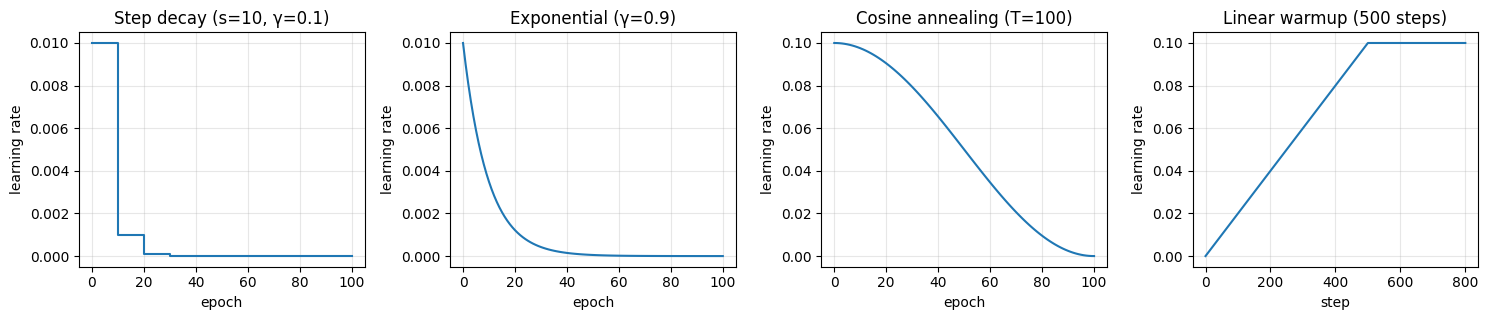

In [10]:
# Draw the four schedules.
ep = list(range(0, 101))
fig, ax = plt.subplots(1, 4, figsize=(15, 3.3))
ax[0].step(ep, [step_decay(e) for e in ep], where="post");        ax[0].set_title("Step decay (s=10, γ=0.1)")
ax[1].plot(ep, [exponential_decay(e) for e in ep]);               ax[1].set_title("Exponential (γ=0.9)")
ax[2].plot(ep, [cosine_annealing(e) for e in ep]);                ax[2].set_title("Cosine annealing (T=100)")
st = list(range(0, 801))
ax[3].plot(st, [linear_warmup(s) for s in st]);                   ax[3].set_title("Linear warmup (500 steps)")
for k, axis in enumerate(ax):
    axis.set_xlabel("epoch" if k < 3 else "step"); axis.set_ylabel("learning rate"); axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Common pitfall — a schedule does not remove a hyperparameter.** Cosine annealing replaced one number, $\eta$, by three: $\eta_0$, $\eta_{min}$ and $T$. Step decay replaced it by $\eta_0$, $\gamma$ and $s$. Every function above has *more* arguments than the constant it replaced. Those arguments belong in the search space or in the write-up, not in a default value nobody recorded.

## Checkpoint

### Q1. Give the four schedules and their formulas.
Step: $\eta_0\gamma^{\lfloor t/s\rfloor}$. Exponential: $\eta_0\gamma^t$. Cosine: $\eta_{min}+\tfrac12(\eta_0-\eta_{min})(1+\cos(\pi t/T))$. Warmup: $\eta_0\min(1,t/T_w)$.

### Q2. Why decay the learning rate at all?
Large steps early move quickly towards a good region; small steps late let the iterates settle into the minimum instead of bouncing around it (the stability window of Part 2 caps the useful step).

### Q3. Why use warmup?
At the start the weights are random and the curvature can be large, so a full-size step may leave the stable window; ramping η up avoids that.

### Q4. Does adopting a schedule reduce the number of hyperparameters?
No — it increases it (cosine: η₀, η_min, T; step: η₀, γ, s).


# **Part 4 — Batch Size**  *(Experiment 4)*

**Aim:** compute updates per epoch and *measure* the $1/B$ fall in gradient variance instead of taking it on trust.

With $N$ training images and mini-batch size $B$, an epoch performs $\lceil N/B\rceil$ updates (the short last batch still counts, though frameworks differ on whether they keep it). A mini-batch gradient is an unbiased estimate of the full gradient whose variance falls as $1/B$, so a larger batch gives a cleaner gradient but fewer updates per epoch. A cleaner gradient tolerates a larger step, so the **linear scaling rule** is the usual first guess for the new learning rate.

**Updates per epoch**

$\lceil N/B\rceil$

**Gradient variance**

$\mathrm{Var}[g_B]=\sigma^2/B$

**Linear scaling rule**

$\eta_{new}=\eta_{old}\cdot\frac{B_{new}}{B_{old}}$

In [11]:
def updates_per_epoch(N, B):
    """ceil(N / B): the short final batch still counts."""
    return math.ceil(N / B)

def scaled_lr(eta, B_old, B_new):
    """The linear scaling rule."""
    return eta * B_new / B_old

print("N=50,000 B=128 ->", updates_per_epoch(50_000, 128), "updates")
print("N=50,000 B=256 ->", updates_per_epoch(50_000, 256), "updates")
print("N=50,000 B=512 ->", updates_per_epoch(50_000, 512), "updates")
print("lr 0.05 at B=128 becomes", scaled_lr(0.05, 128, 256), "at B=256")
print("lr 0.05 at B=128 becomes", scaled_lr(0.05, 128, 512), "at B=512")
print("drop_last=True at B=128 would give", 50_000 // 128, "instead of 391")

N=50,000 B=128 -> 391 updates
N=50,000 B=256 -> 196 updates
N=50,000 B=512 -> 98 updates
lr 0.05 at B=128 becomes 0.1 at B=256
lr 0.05 at B=128 becomes 0.2 at B=512
drop_last=True at B=128 would give 390 instead of 391


**Result:** matches the manual. 50,000/128 = 390.6, rounded **up** to **391**; 196 at B = 256; 98 at B = 512. The linear rule doubles the learning rate when the batch doubles (0.05 → 0.1 → 0.2). `drop_last=True` would discard the short final batch and give 390 updates instead of 391.


Now measure the $1/B$ law: draw many mini-batches at each size, take the gradient of each, and look at the variance across draws.


In [12]:
torch.manual_seed(0)
data = torch.randn(4096, 20)                    # 4096 random "training examples"
w = torch.randn(20, requires_grad=True)         # a weight vector

def gradient_variance(B, trials=200):
    """Draw `trials` mini-batches of size B, take the gradient of each, return the variance across draws."""
    grads = []
    for _ in range(trials):
        idx = torch.randint(0, data.shape[0], (B,))
        loss = ((data[idx] @ w) ** 2).mean()
        g, = torch.autograd.grad(loss, w)
        grads.append(g)
    return torch.stack(grads).var(dim=0).mean().item()

baseline = gradient_variance(8)
sizes, variances = [8, 16, 32, 64, 128], []
for B in sizes:
    v = gradient_variance(B)
    variances.append(v)
    print(f"B={B:<4} variance {v:9.4f}   measured drop {baseline / v:5.2f}x"
          f"   1/B predicts {B // 8}x")
print("\n(200 draws per size, so the measured ratios carry a few percent of sampling error of their own)")

B=8    variance   15.4724   measured drop  0.95x   1/B predicts 1x
B=16   variance    7.7227   measured drop  1.91x   1/B predicts 2x
B=32   variance    3.6622   measured drop  4.03x   1/B predicts 4x
B=64   variance    1.9980   measured drop  7.38x   1/B predicts 8x
B=128  variance    0.9500   measured drop 15.52x   1/B predicts 16x

(200 draws per size, so the measured ratios carry a few percent of sampling error of their own)


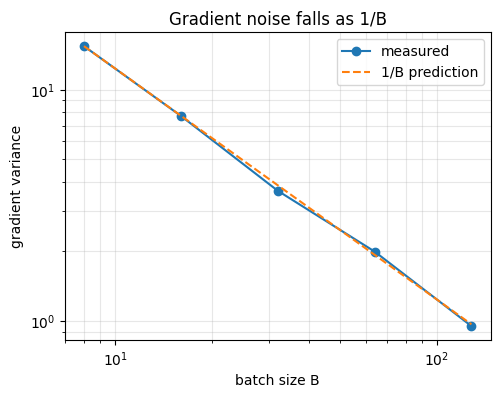

In [13]:
# Measured variance against the 1/B prediction (both on log-log axes -> a straight line of slope -1).
plt.figure(figsize=(5.5, 4))
plt.loglog(sizes, variances, "o-", label="measured")
plt.loglog(sizes, [variances[0] * 8 / B for B in sizes], "--", label="1/B prediction")
plt.xlabel("batch size B"); plt.ylabel("gradient variance")
plt.title("Gradient noise falls as 1/B"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.show()

**Result:** the measured drops follow $1/B$ closely:

| B | variance | measured drop | 1/B predicts |
|---|---|---|---|
| 8 | 15.47 | 0.95× | 1× |
| 16 | 7.72 | 1.91× | 2× |
| 32 | 3.66 | 4.03× | 4× |
| 64 | 2.00 | 7.38× | 8× |
| 128 | 0.95 | 15.52× | 16× |

The ratios are within a few percent of the prediction (the 0.95× at B = 8 is just sampling noise: the baseline and the B = 8 row are two *different* sets of 200 draws). On the log-log plot the measured points lie on a straight line of slope −1.

## Checkpoint

### Q1. Updates per epoch for N = 50,000?
$\lceil N/B\rceil$: 391 (B = 128), 196 (B = 256), 98 (B = 512).

### Q2. How does gradient variance depend on B?
$\mathrm{Var}[g_B]=\sigma^2/B$. Measured: going from B = 8 to B = 128 cut the variance 15.5× (prediction 16×).

### Q3. State the linear scaling rule and use it.
$\eta_{new}=\eta_{old}B_{new}/B_{old}$: 0.05 at B = 128 becomes 0.1 at B = 256 and 0.2 at B = 512. It is a first guess, not a guarantee.

### Q4. What is the whole trade-off in two lines?
Doubling the batch halves the updates per epoch and halves the gradient variance: a cleaner gradient paid for with fewer steps. At B = 512 the network gets 98 updates per epoch instead of 391 — a quarter of the progress unless the learning rate and the epoch budget rise.


# **Part 5 — Grid Search and Random Search**  *(Experiment 5)*

**Aim:** compute the cost of grid search and the probability that random search finds a good region, and confirm the formula by simulation.

**Grid search** tries every combination of a few candidate values per hyperparameter, so the number of trials is the product of the candidate counts and grows exponentially with the number of hyperparameters:

$$N_{trials}=\prod_{j=1}^{d}k_j$$

**Random search** draws each configuration independently. If a fraction $p$ of the space is "good", one trial misses it with probability $1-p$, so $n$ independent trials find it at least once with probability

$$P(\text{at least one good trial})=1-(1-p)^n \qquad\Rightarrow\qquad n\;\ge\;\frac{\ln(1-P)}{\ln(1-p)}$$


In [14]:
def grid_trials(counts):
    """Number of trials = product of the candidate counts."""
    return functools.reduce(operator.mul, counts, 1)

print("5 x 4 x 3 grid     =", grid_trials([5, 4, 3]), "trials")
print("4 x 3 x 2 x 2 grid =", grid_trials([4, 3, 2, 2]), "trials")
print("at 30 min each     =", grid_trials([4, 3, 2, 2]) * 30 / 60, "hours")

5 x 4 x 3 grid     = 60 trials
4 x 3 x 2 x 2 grid = 48 trials
at 30 min each     = 24.0 hours


**Result:** matches the manual — 5×4×3 = **60** trials; 4×3×2×2 = **48** trials, which at 30 minutes each is **24 hours** of training.


Now check the two random-search formulas, and confirm the first by simulation rather than only by algebra.


In [15]:
def probability_of_hit(p_good, n):
    """P = 1 - (1 - p)^n"""
    return 1 - (1 - p_good) ** n

def trials_for_confidence(p_good, confidence):
    """n >= ln(1 - P) / ln(1 - p)"""
    return math.ceil(math.log(1 - confidence) / math.log(1 - p_good))

print("p=0.10, n=20 trials ->", round(probability_of_hit(0.10, 20), 6))
print("p=0.10, 95% needs   ->", trials_for_confidence(0.10, 0.95), "trials")
print("p=0.08, 95% needs   ->", trials_for_confidence(0.08, 0.95), "trials")

# Check the first formula by simulation rather than only by algebra:
# 20,000 imaginary searches of 20 trials each; a trial is "good" with probability 0.10.
torch.manual_seed(0)
simulated = (torch.rand(20_000, 20) < 0.10).any(dim=1).float().mean().item()
print("simulation, p=0.10, n=20 ->", round(simulated, 4))

p=0.10, n=20 trials -> 0.878423
p=0.10, 95% needs   -> 29 trials
p=0.08, 95% needs   -> 36 trials
simulation, p=0.10, n=20 -> 0.8784


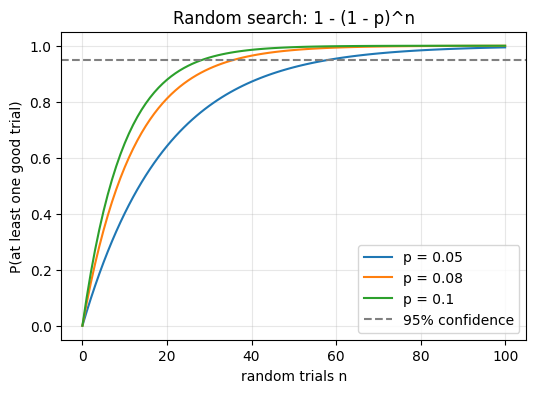

In [16]:
# P(at least one good trial) against the number of random trials, for three sizes of good region.
ns = list(range(0, 101))
plt.figure(figsize=(6, 4))
for p in (0.05, 0.08, 0.10):
    plt.plot(ns, [probability_of_hit(p, n) for n in ns], label=f"p = {p}")
plt.axhline(0.95, color="grey", linestyle="--", label="95% confidence")
plt.xlabel("random trials n"); plt.ylabel("P(at least one good trial)")
plt.title("Random search: 1 - (1 - p)^n"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Result:** matches the manual. With p = 0.10: 20 trials give $1-0.9^{20}=$ **0.878423**; 95% confidence needs ⌈ln 0.05 / ln 0.90⌉ = ⌈28.4⌉ = **29** trials. With p = 0.08 it needs **36**. The simulation (20,000 imaginary searches) gives **0.8784**, agreeing with the formula to four decimals ✅.

**Common pitfall — what the probability formula does not say.** It assumes you already know what fraction of the space is good, and that the space was defined sensibly. It says nothing about *how* good "good" is. A search space with the optimum outside its bounds has p = 0, and no number of trials will help.


## Tasks

### Exercise 3 — 99% confidence when the good region is 5% of the space
Find the number of random trials and compare it with a grid of 4 hyperparameters × 5 values each.


In [17]:
# Exercise 3: 99% confidence when the good region is 5% of the space, versus a 4-hyperparameter x 5-value grid.
n_random = trials_for_confidence(0.05, 0.99)
n_grid = grid_trials([5, 5, 5, 5])
print("random search, p=0.05, 99% confidence :", n_random, "trials")
print("grid search, 4 hyperparameters x 5 values :", n_grid, "trials")
print(f"grid / random = {n_grid / n_random:.1f}x")
print("check: P(hit) with", n_random, "trials =", round(probability_of_hit(0.05, n_random), 4))

random search, p=0.05, 99% confidence : 90 trials
grid search, 4 hyperparameters x 5 values : 625 trials
grid / random = 6.9x
check: P(hit) with 90 trials = 0.9901


**Result:** by hand, ln(0.01)/ln(0.95) = −4.605/−0.0513 = 89.8 → **90** random trials (check: $1-0.95^{90}=0.9901$). The 4-hyperparameter, 5-value grid needs $5^4=$ **625** trials — **6.9× more**. Random search's cost depends on how big the good region is, not on how many hyperparameters there are; the grid's cost multiplies with every extra hyperparameter.

## Checkpoint

### Q1. How many trials does a grid need?
The product of the candidate counts: 5×4×3 = 60; 4×3×2×2 = 48 (24 hours at 30 min each).

### Q2. What is the chance random search hits a good region?
$P=1-(1-p)^n$. For p = 0.10 and n = 20: 0.8784 (formula and simulation agree).

### Q3. How many trials for confidence P?
$n\ge\ln(1-P)/\ln(1-p)$: 29 trials for 95% at p = 0.10; 36 at p = 0.08; 90 for 99% at p = 0.05.

### Q4. What does the formula not tell you?
It assumes p is known and the space is right. If the optimum lies outside the bounds, p = 0 and more trials cannot help.


# **Part 6 — Expected Improvement**  *(Experiment 6)*

**Aim:** evaluate Expected Improvement for two candidates and read off its exploitation and exploration terms.

Grid and random search ignore what earlier trials revealed. **Bayesian optimization** fits a cheap probabilistic model to the validation scores seen so far; for any untried configuration it predicts a mean $\mu$ and an uncertainty $\sigma$, and an *acquisition function* turns the two into one score that balances **exploitation** (low predicted loss) against **exploration** (large uncertainty). The highest score is trained next. A common choice is Expected Improvement: with $f_{best}$ the lowest validation loss so far and $\xi$ a small exploration margin,

$$EI=(f_{best}-\mu-\xi)\,\Phi(Z)+\sigma\,\varphi(Z), \qquad Z=\frac{f_{best}-\mu-\xi}{\sigma}$$

where $\Phi$ and $\varphi$ are the standard normal CDF and PDF. The first term rewards a low predicted mean, the second rewards high uncertainty. Candidate A has the better mean; candidate B has the larger uncertainty. Which does EI prefer?


In [18]:
standard_normal = torch.distributions.Normal(0.0, 1.0)   # N(0,1): gives us Phi (cdf) and phi (pdf)

def expected_improvement(mu, sigma, f_best, xi=0.01):
    """EI = (f_best - mu - xi)*Phi(Z) + sigma*phi(Z)."""
    z = torch.tensor((f_best - mu - xi) / sigma)
    Phi = standard_normal.cdf(z).item()                  # standard normal CDF
    phi = standard_normal.log_prob(z).exp().item()       # standard normal PDF
    ei = (f_best - mu - xi) * Phi + sigma * phi
    return ei, z.item(), Phi, phi

f_best, xi = 0.42, 0.01   # best loss so far, exploration margin
for name, mu, sigma in [("A", 0.35, 0.08), ("B", 0.40, 0.15)]:
    ei, z, Phi, phi = expected_improvement(mu, sigma, f_best, xi)
    print(f"{name}: mu={mu}  sigma={sigma}   Z={z:.4f}  Phi={Phi:.4f}  phi={phi:.4f}"
          f"   EI = {ei:.5f}")

A: mu=0.35  sigma=0.08   Z=0.7500  Phi=0.7734  phi=0.3011   EI = 0.07049
B: mu=0.4  sigma=0.15   Z=0.0667  Phi=0.5266  phi=0.3981   EI = 0.06497


**Result:** matches the manual. **A wins, but only just:** EI = 0.07049 against 0.06497. By hand for A: Z = (0.42 − 0.35 − 0.01)/0.08 = 0.75, Φ(0.75) = 0.7734, φ(0.75) = 0.3011, so EI = 0.06·0.7734 + 0.08·0.3011 = 0.0464 + 0.0241 = **0.0705** ✅.


A: exploitation term = 0.0464   exploration term = 0.0241   EI = 0.07049
B: exploitation term = 0.0053   exploration term = 0.0597   EI = 0.06497


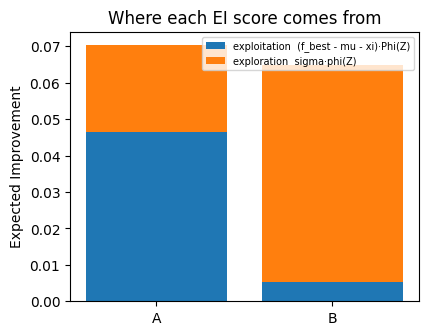

In [19]:
# Split EI into its two terms: exploitation (low predicted mean) and exploration (high uncertainty).
parts = {}
for name, mu, sigma in [("A", 0.35, 0.08), ("B", 0.40, 0.15)]:
    ei, z, Phi, phi = expected_improvement(mu, sigma, f_best, xi)
    exploit, explore = (f_best - mu - xi) * Phi, sigma * phi
    parts[name] = (exploit, explore)
    print(f"{name}: exploitation term = {exploit:.4f}   exploration term = {explore:.4f}   EI = {exploit + explore:.5f}")

plt.figure(figsize=(4.5, 3.5))
plt.bar(["A", "B"], [parts["A"][0], parts["B"][0]], label="exploitation  (f_best - mu - xi)·Phi(Z)")
plt.bar(["A", "B"], [parts["A"][1], parts["B"][1]], bottom=[parts["A"][0], parts["B"][0]],
        label="exploration  sigma·phi(Z)")
plt.ylabel("Expected Improvement"); plt.title("Where each EI score comes from")
plt.legend(fontsize=7); plt.show()

**Result:** the two scores have very different origins.

| | exploitation term | exploration term | EI |
|---|---|---|---|
| A (μ = 0.35, σ = 0.08) | 0.0464 | 0.0241 | 0.07049 |
| B (μ = 0.40, σ = 0.15) | 0.0053 | 0.0597 | 0.06497 |

Most of A's appeal is its low predicted mean (**exploitation**); almost all of B's appeal is its uncertainty (**exploration**). Two different arguments give nearly the same score — that near-tie is the trade-off made arithmetic.


## Tasks

### Exercise — Move the balance (also viva question 4)
Raise $\xi$, set $\sigma_B=0.20$, and halve $\sigma_B$ to 0.075, and watch which candidate wins.


In [20]:
# Try the two experiments suggested in the checkpoint, plus halving B's uncertainty (viva question 4).
ei_A = expected_improvement(0.35, 0.08, f_best, xi)[0]
print(f"EI of A (reference)                 : {ei_A:.5f}")
for label, sigma_b, xi_ in [("B with sigma = 0.15 (original)", 0.15, 0.01),
                            ("B with sigma = 0.20            ", 0.20, 0.01),
                            ("B with sigma = 0.075 (halved)  ", 0.075, 0.01)]:
    ei_b = expected_improvement(0.40, sigma_b, f_best, xi_)[0]
    print(f"EI of {label}: {ei_b:.5f}   -> {'B' if ei_b > ei_A else 'A'} wins")

print("\nRaising the exploration margin xi (A and B with their original sigmas):")
for xi_ in [0.0, 0.01, 0.05, 0.10]:
    a_ = expected_improvement(0.35, 0.08, f_best, xi_)[0]
    b_ = expected_improvement(0.40, 0.15, f_best, xi_)[0]
    print(f"  xi={xi_:<5}  EI_A = {a_:.5f}   EI_B = {b_:.5f}   winner: {'A' if a_ > b_ else 'B'}")

EI of A (reference)                 : 0.07049
EI of B with sigma = 0.15 (original): 0.06497   -> A wins
EI of B with sigma = 0.20            : 0.08489   -> B wins
EI of B with sigma = 0.075 (halved)  : 0.03519   -> A wins

Raising the exploration margin xi (A and B with their original sigmas):
  xi=0.0    EI_A = 0.07841   EI_B = 0.07037   winner: A
  xi=0.01   EI_A = 0.07049   EI_B = 0.06497   winner: A
  xi=0.05   EI_A = 0.04291   EI_B = 0.04603   winner: B
  xi=0.1    EI_A = 0.01913   EI_B = 0.02816   winner: B


**Result:** with $\sigma_B=0.20$, B's EI rises to **0.0849** and overtakes A (0.0705). With $\sigma_B$ **halved** to 0.075, B's score collapses to **0.0352** (−46%), because almost all of it came from the $\sigma\varphi(Z)$ term, and A wins comfortably. Raising $\xi$ shifts the balance towards exploration: B overtakes A once $\xi\ge0.05$ (EI_B = 0.0460 vs EI_A = 0.0429).

## Checkpoint

### Q1. What does an acquisition function do?
Turns the surrogate's prediction (μ, σ) for an untried configuration into one score; the highest score is trained next.

### Q2. Write Expected Improvement and name the two terms.
$EI=(f_{best}-\mu-\xi)\Phi(Z)+\sigma\varphi(Z)$. First term = exploitation (low predicted loss), second = exploration (high uncertainty).

### Q3. Which term decided candidate B's score, and what if σ_B were halved?
The second (0.0597 of 0.0650). Halving σ_B to 0.075 drops EI_B to 0.0352, well below A's 0.0705.

### Q4. What does ξ do?
It is the exploration margin: larger ξ lowers the exploitation term and pushes the choice towards uncertain candidates (B wins from ξ = 0.05).


# **Part 7 — Successive Halving**  *(Experiment 7)*

**Aim:** generate the rungs of successive halving and account for its budget.

Training every configuration to convergence is wasteful: one that is clearly poor after a few epochs rarely wins later. **Successive halving** gives a small budget to many configurations, discards the worst, and gives the survivors more. Start with $n$ configurations, an initial budget of $r_0$ epochs each and a reduction factor $\eta_{SH}$ (commonly 3; *not* the learning rate). Rung $k$ keeps $n_k$ configurations, each trained for $r_k$ epochs:

$$n_k=\Big\lfloor \frac{n}{\eta_{SH}^{\,k}}\Big\rfloor,\qquad r_k=r_0\,\eta_{SH}^{\,k},\qquad \text{budget}=\sum_{k=0}^{K} n_k r_k$$

The design is balanced: the population shrinks by the same factor by which the per-trial budget grows, so every rung costs about the same ($n_k r_k = n r_0$). Generate the rungs for $n=27$ and $n=81$ and compare each total with training every configuration for the full budget.


In [21]:
def rungs(n, r0, eta):
    """n_k = floor(n / eta^k), r_k = r0 * eta^k  (eta is the reduction factor)."""
    out, n_k, r_k = [], n, r0
    while True:
        out.append((n_k, r_k))
        if n_k <= 1 or n_k // eta < 1:     # one survivor left (or no further halving is possible)
            return out
        n_k, r_k = math.floor(n_k / eta), r_k * eta

for n, r0, eta in [(27, 1, 3), (81, 1, 3)]:
    schedule = rungs(n, r0, eta)
    budget = sum(n_k * r_k for n_k, r_k in schedule)   # sum of n_k * r_k
    brute_force = n * schedule[-1][1]                  # every configuration trained for the full budget
    print(f"n={n}, r0={r0}, eta={eta}")
    for k, (n_k, r_k) in enumerate(schedule):
        print(f"   rung {k}: {n_k:>3} configs x {r_k:>2} epochs = {n_k * r_k:>4} epoch-units")
    print(f"   total {budget}   brute force {brute_force}"
          f"   saving {brute_force / budget:.2f}x\n")

n=27, r0=1, eta=3
   rung 0:  27 configs x  1 epochs =   27 epoch-units
   rung 1:   9 configs x  3 epochs =   27 epoch-units
   rung 2:   3 configs x  9 epochs =   27 epoch-units
   rung 3:   1 configs x 27 epochs =   27 epoch-units
   total 108   brute force 729   saving 6.75x

n=81, r0=1, eta=3
   rung 0:  81 configs x  1 epochs =   81 epoch-units
   rung 1:  27 configs x  3 epochs =   81 epoch-units
   rung 2:   9 configs x  9 epochs =   81 epoch-units
   rung 3:   3 configs x 27 epochs =   81 epoch-units
   rung 4:   1 configs x 81 epochs =   81 epoch-units
   total 405   brute force 6561   saving 16.20x



**Result:** matches the manual. Twenty-seven configurations cost **108** epoch-units instead of 729 (**6.75×** cheaper); eighty-one cost **405** instead of 6,561 (**16.2×**). Every rung costs the same (27 or 81 units). The method gets *better* the more configurations you throw at it — the opposite of grid search. The price is the risk of discarding a slow starter: a configuration with a long warmup can be eliminated at rung 0 despite being the eventual winner. **Hyperband** addresses this by running several brackets with different starting budgets.


## Tasks

### Exercise 4 — n = 64 with η_SH = 2 and η_SH = 4
Compare the total budgets. Which reduction factor is cheapest, and what does it risk?


In [22]:
# Exercise 4: n = 64 with reduction factors 2 and 4.
results = {}
for eta in (2, 4):
    schedule = rungs(64, 1, eta)
    budget = sum(n_k * r_k for n_k, r_k in schedule)
    brute_force = 64 * schedule[-1][1]
    results[eta] = budget
    print(f"n=64, r0=1, eta_SH={eta}")
    for k, (n_k, r_k) in enumerate(schedule):
        print(f"   rung {k}: {n_k:>3} configs x {r_k:>2} epochs = {n_k * r_k:>3} epoch-units")
    print(f"   rungs {len(schedule)}   total {budget}   brute force {brute_force}   saving {brute_force / budget:.2f}x\n")

cheapest = min(results, key=results.get)
print("cheapest reduction factor:", cheapest, "->", results[cheapest], "epoch-units")
print("survivors after rung 0 (only 1 epoch of evidence):",
      {eta: rungs(64, 1, eta)[1][0] for eta in (2, 4)})

n=64, r0=1, eta_SH=2
   rung 0:  64 configs x  1 epochs =  64 epoch-units
   rung 1:  32 configs x  2 epochs =  64 epoch-units
   rung 2:  16 configs x  4 epochs =  64 epoch-units
   rung 3:   8 configs x  8 epochs =  64 epoch-units
   rung 4:   4 configs x 16 epochs =  64 epoch-units
   rung 5:   2 configs x 32 epochs =  64 epoch-units
   rung 6:   1 configs x 64 epochs =  64 epoch-units
   rungs 7   total 448   brute force 4096   saving 9.14x

n=64, r0=1, eta_SH=4
   rung 0:  64 configs x  1 epochs =  64 epoch-units
   rung 1:  16 configs x  4 epochs =  64 epoch-units
   rung 2:   4 configs x 16 epochs =  64 epoch-units
   rung 3:   1 configs x 64 epochs =  64 epoch-units
   rungs 4   total 256   brute force 4096   saving 16.00x

cheapest reduction factor: 4 -> 256 epoch-units
survivors after rung 0 (only 1 epoch of evidence): {2: 32, 4: 16}


**Result:** η_SH = 2 needs 7 rungs of 64 units = **448** epoch-units (9.14× cheaper than the 4,096 of brute force); η_SH = 4 needs 4 rungs of 64 units = **256** (16×). **The larger reduction factor is cheapest** — fewer rungs, each costing $n r_0=64$ — but it is also the most aggressive: after only **one epoch** of evidence it keeps just 16 of 64 configurations (η = 2 keeps 32), so a slow starter is far more likely to be eliminated before it shows its quality.

## Checkpoint

### Q1. Give the rung formulas and the budget.
$n_k=\lfloor n/\eta_{SH}^k\rfloor$, $r_k=r_0\eta_{SH}^k$, budget $=\sum n_k r_k$.

### Q2. Why does every rung cost the same?
$n_k r_k=(n/\eta^k)(r_0\eta^k)=nr_0$: the population shrinks by exactly the factor by which the budget per trial grows.

### Q3. How much does it save?
n = 27: 108 vs 729 (6.75×). n = 81: 405 vs 6,561 (16.2×). The saving grows with n.

### Q4. What failure mode does it accept?
Discarding a slow starter (e.g. a long warmup) at an early rung. Hyperband runs several brackets with different starting budgets to reduce this risk.


# **Part 8 — A Real Search on CIFAR-10**  *(Experiment 8)*

**Aim:** combine the earlier Parts into a real search — nine random configurations of learning rate, weight decay and dropout, reduced by successive halving ($\eta_{SH}=3$) so that weak configurations stop after one epoch — **without ever touching the test set**.

The search costs $9\times1+3\times3+1\times9=27$ epoch-units instead of the 81 needed to train all nine for nine epochs. Each configuration is trained with **Adam**, an optimizer that adapts the step size for every weight (learning rates around 1e-3 are typical for it).

**Data first.** The training set is subsampled to keep the search quick. The validation split is carved out of the *training* data, never out of the test set: the test set is reserved for one final evaluation and is not loaded anywhere in this Part. *(The first run downloads CIFAR-10, about 170 MB.)*


In [23]:
from torch.utils.data import Subset, DataLoader   # Subset = a slice of a dataset; DataLoader = batching

transform = transforms.Compose([
    transforms.ToTensor(),                                      # PIL image -> tensor in [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),     # rescale to [-1, 1]
])

# Only the TRAIN split is loaded (50,000 images); the 10,000-image test split is never touched here.
cifar_train = torchvision.datasets.CIFAR10(root="./data", train=True,
                                           download=True, transform=transform)

train_subset = Subset(cifar_train, range(0, 5000))        # search training split
val_subset   = Subset(cifar_train, range(5000, 7000))     # search validation split (from TRAIN, not test)

print(len(train_subset), "training images │", len(val_subset), "validation images")
print("the test split is not loaded at all in this experiment")

100%|██████████| 170M/170M [09:41<00:00, 293kB/s]


5000 training images │ 2000 validation images
the test split is not loaded at all in this experiment


**Result:** 5,000 training images and 2,000 validation images, both slices of CIFAR-10's 50,000-image **train** split (indices 0–4,999 and 5,000–6,999, so they do not overlap). Only the train split is loaded; the 10,000 test images are never read.


**The search space.** Learning rate and weight decay span several orders of magnitude, so they are sampled on a **logarithmic scale**: draw an exponent $u$ uniformly in $[u_{min},u_{max}]$ and set the value to $10^u$.

$$\eta = 10^{u},\qquad u\sim U(u_{min},u_{max})$$

Dropout lives in a bounded interval, so it is sampled **linearly**. The random generator is seeded, so everyone gets the same nine configurations.


In [24]:
SEARCH_SPACE = {
    "lr":           lambda r: 10 ** r.uniform(-4.0, -1.5),   # log scale: exponent u ~ U(-4, -1.5)
    "weight_decay": lambda r: 10 ** r.uniform(-6.0, -3.0),   # log scale: exponent u ~ U(-6, -3)
    "dropout":      lambda r: r.uniform(0.0, 0.6),           # linear scale: bounded interval
}

rng = random.Random(0)                                       # fixed seed -> the same nine configurations every run
configs = [{k: sample(rng) for k, sample in SEARCH_SPACE.items()} for _ in range(9)]

for i, c in enumerate(configs):
    print(f"cfg {i}:  lr={c['lr']:.2e}   wd={c['weight_decay']:.2e}   p={c['dropout']:.2f}")

cfg 0:  lr=1.29e-02   wd=1.88e-04   p=0.25
cfg 1:  lr=4.44e-04   wd=3.42e-05   p=0.24
cfg 2:  lr=9.11e-03   wd=8.13e-06   p=0.29
cfg 3:  lr=2.87e-03   wd=5.30e-04   p=0.30
cfg 4:  lr=5.07e-04   wd=1.85e-04   p=0.37
cfg 5:  lr=4.23e-04   wd=5.36e-04   p=0.59
cfg 6:  lr=1.06e-02   wd=5.09e-04   p=0.19
cfg 7:  lr=6.68e-03   wd=4.97e-04   p=0.41
cfg 8:  lr=1.51e-03   wd=2.00e-06   p=0.26


**Result:** the nine configurations are identical to the manual's (fixed seed `random.Random(0)`): e.g. cfg 0 has lr = 1.29e-02, wd = 1.88e-04, p = 0.25. Learning rates run from 4.2e-04 to 1.3e-02 and weight decays from 2e-06 to 5.4e-04.

The next cell shows *why* the log scale matters.


In [25]:
# Why a log scale? Sample the learning-rate range 1e-4 ... 10^-1.5 both ways and count draws per decade.
rr = random.Random(1)
lin = [rr.uniform(1e-4, 10 ** -1.5) for _ in range(10_000)]          # uniform on the VALUE
log = [10 ** rr.uniform(-4.0, -1.5) for _ in range(10_000)]          # uniform on the EXPONENT
def decade_share(xs):
    edges = [1e-4, 1e-3, 1e-2, 10 ** -1.5]
    return [sum(lo <= x < hi for x in xs) / len(xs) for lo, hi in zip(edges[:-1], edges[1:])]
print("share of draws in  [1e-4,1e-3)   [1e-3,1e-2)   [1e-2,0.0316)")
print("uniform on value :", [f"{s:6.1%}" for s in decade_share(lin)])
print("uniform on log10 :", [f"{s:6.1%}" for s in decade_share(log)])

share of draws in  [1e-4,1e-3)   [1e-3,1e-2)   [1e-2,0.0316)
uniform on value : ['  3.0%', ' 28.6%', ' 68.4%']
uniform on log10 : [' 39.3%', ' 40.6%', ' 20.1%']


**Result:** sampling the learning-rate value uniformly puts about **68%** of the draws in the top decade and only **3%** in the lowest; sampling the exponent uniformly gives roughly 39% / 41% / 20% (the last decade is narrower because the range ends at $10^{-1.5}$). Log-uniform sampling gives every order of magnitude a fair share of the trials — which matters because the learning rate acts multiplicatively (Part 2).


**Training one configuration.** `train_and_score` builds a fresh `SmallCNN`, trains it with Adam for the requested number of epochs, and returns its **validation loss** (a score to select with, not a measure of generalisation). Every call reseeds, so all configurations start from the same initial weights and differ only in their hyperparameters.


In [26]:
def train_and_score(cfg, epochs, seed=0):
    """Train one configuration for a given budget and return its validation loss."""
    torch.manual_seed(seed)                                   # same initial weights for every configuration
    net = SmallCNN(dropout=cfg["dropout"]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=cfg["lr"],
                           weight_decay=cfg["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=256)

    for _ in range(epochs):                                   # ---- training ----
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            criterion(net(x), y).backward()
            opt.step()

    net.eval()                                                # ---- validation loss (no gradients) ----
    total_loss = seen = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            total_loss += criterion(net(x), y).item() * y.size(0)
            seen += y.size(0)
    return total_loss / seen

**Successive halving.** Rung 0 trains all nine configurations for 1 epoch; the best third (3) survive and are retrained for 3 epochs; the best one of those is retrained for 9. Each rung retrains **from scratch**, which is what the budget formula of Part 7 accounts for.


In [27]:
history = []        # (rung, config index, config, validation loss) for every trial - used for the analysis below

def successive_halving(configs, r0=1, eta=3):
    survivors, budget, rung = list(configs), 0, 0
    while True:
        print(f"rung {rung}: {len(survivors)} configs x {r0} epoch(s)")
        scored = []
        for c in survivors:
            loss = train_and_score(c, r0)                     # retrain from scratch for r0 epochs
            budget += r0
            scored.append((loss, c))
            history.append((rung, configs.index(c), c, loss))
            print(f"   lr={c['lr']:.2e} wd={c['weight_decay']:.2e}"
                  f" p={c['dropout']:.2f}   val loss {loss:.4f}")
        scored.sort(key=lambda pair: pair[0])                 # best (lowest loss) first
        if len(survivors) == 1:
            return scored[0], budget
        survivors = [c for _, c in scored[:max(1, len(survivors) // eta)]]   # keep the best 1/eta
        r0 *= eta                                             # survivors get eta times more epochs
        rung += 1
        print()

(best_loss, best_cfg), budget = successive_halving(configs)

print(f"\nbest configuration: lr={best_cfg['lr']:.2e}"
      f" wd={best_cfg['weight_decay']:.2e} p={best_cfg['dropout']:.2f}")
print(f"validation loss {best_loss:.4f}")
print(f"budget spent {budget} epoch-units │ training all nine for 9 epochs would cost 81")

rung 0: 9 configs x 1 epoch(s)
   lr=1.29e-02 wd=1.88e-04 p=0.25   val loss 2.3027
   lr=4.44e-04 wd=3.42e-05 p=0.24   val loss 1.9827
   lr=9.11e-03 wd=8.13e-06 p=0.29   val loss 2.3028
   lr=2.87e-03 wd=5.30e-04 p=0.30   val loss 1.8057
   lr=5.07e-04 wd=1.85e-04 p=0.37   val loss 1.9715
   lr=4.23e-04 wd=5.36e-04 p=0.59   val loss 2.0078
   lr=1.06e-02 wd=5.09e-04 p=0.19   val loss 2.3029
   lr=6.68e-03 wd=4.97e-04 p=0.41   val loss 2.3031
   lr=1.51e-03 wd=2.00e-06 p=0.26   val loss 1.9177

rung 1: 3 configs x 3 epoch(s)
   lr=2.87e-03 wd=5.30e-04 p=0.30   val loss 1.5791
   lr=1.51e-03 wd=2.00e-06 p=0.26   val loss 1.7493
   lr=5.07e-04 wd=1.85e-04 p=0.37   val loss 1.6773

rung 2: 1 configs x 9 epoch(s)
   lr=2.87e-03 wd=5.30e-04 p=0.30   val loss 1.2248

best configuration: lr=2.87e-03 wd=5.30e-04 p=0.30
validation loss 1.2248
budget spent 27 epoch-units │ training all nine for 9 epochs would cost 81


**Result (read from your own run):** the printout lists the validation loss of every trial rung by rung. Three things are fixed regardless of hardware or seed:

- the **nine configurations** are the ones printed above;
- the rungs are **9 → 3 → 1 configurations at 1 → 3 → 9 epochs**, each rung costing 9 epoch-units;
- the **budget is 27 epoch-units** against 81 for brute force — a **3× saving**.

The individual losses and the winning configuration depend on the GPU/CPU and the PyTorch version, so the next cell reads them off the recorded history instead of quoting them.


rung-0 ranking (1 epoch each):
  #1  cfg 3   lr=2.87e-03   val loss 1.8057
  #2  cfg 8   lr=1.51e-03   val loss 1.9177
  #3  cfg 4   lr=5.07e-04   val loss 1.9715
  #4  cfg 1   lr=4.44e-04   val loss 1.9827
  #5  cfg 5   lr=4.23e-04   val loss 2.0078
  #6  cfg 0   lr=1.29e-02   val loss 2.3027
  #7  cfg 2   lr=9.11e-03   val loss 2.3028
  #8  cfg 6   lr=1.06e-02   val loss 2.3029
  #9  cfg 7   lr=6.68e-03   val loss 2.3031

learning rates of the 3 survivors    : 5.07e-04 ... 2.87e-03   (median 1.51e-03)
learning rates of the 6 eliminated   : 4.23e-04 ... 1.29e-02
configurations with lr >= 5e-3       : 4 of 9, 0 of them survived rung 0

trials per rung: {0: 9, 1: 3, 2: 1} │ total budget: 27 epoch-units


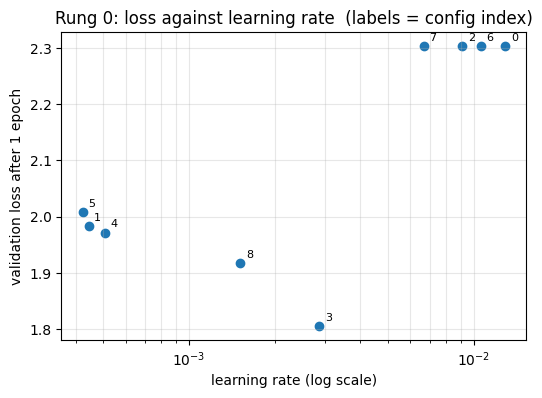

In [28]:
# ---- Read the search results off the recorded history (nothing here is typed in by hand) ----
rung0 = sorted([h for h in history if h[0] == 0], key=lambda h: h[3])      # best -> worst at rung 0
print("rung-0 ranking (1 epoch each):")
for rank, (_, i, c, loss) in enumerate(rung0, 1):
    print(f"  #{rank}  cfg {i}   lr={c['lr']:.2e}   val loss {loss:.4f}")

survivors0 = [h for h in rung0[:3]]
eliminated0 = [h for h in rung0[3:]]
s_lr = [h[2]["lr"] for h in survivors0]
e_lr = [h[2]["lr"] for h in eliminated0]
print(f"\nlearning rates of the 3 survivors    : {min(s_lr):.2e} ... {max(s_lr):.2e}   (median {sorted(s_lr)[1]:.2e})")
print(f"learning rates of the 6 eliminated   : {min(e_lr):.2e} ... {max(e_lr):.2e}")
print(f"configurations with lr >= 5e-3       : {sum(h[2]['lr'] >= 5e-3 for h in history if h[0] == 0)} of 9, "
      f"{sum(h[2]['lr'] >= 5e-3 for h in survivors0)} of them survived rung 0")

by_rung = {}
for rung_, _, _, _ in history:
    by_rung[rung_] = by_rung.get(rung_, 0) + 1
print("\ntrials per rung:", by_rung, "│ total budget:", budget, "epoch-units")

# Loss at rung 0 against learning rate (log x axis): the stability window of Part 2 on a real network.
plt.figure(figsize=(6, 4))
plt.scatter([h[2]["lr"] for h in rung0], [h[3] for h in rung0], c="tab:blue")
for _, i, c, loss in rung0:
    plt.annotate(str(i), (c["lr"], loss), textcoords="offset points", xytext=(4, 4), fontsize=8)
plt.xscale("log")
plt.xlabel("learning rate (log scale)"); plt.ylabel("validation loss after 1 epoch")
plt.title("Rung 0: loss against learning rate  (labels = config index)")
plt.grid(alpha=0.3, which="both"); plt.show()

**How to read this output.** The rung-0 ranking shows which configurations successive halving kept after a single epoch, and the plot shows rung-0 validation loss against learning rate. This is the **stability window of Part 2 on a real network**. In this run the four configurations with lr ≥ 5e-3 (cfg 0, 2, 6, 7: 6.7e-3 to 1.3e-2) all finished at a validation loss of about 2.303 = ln 10, which is chance level for 10 classes: Adam at those rates did not learn at all, and none of them survived rung 0. The five configurations with lr between 4e-4 and 2.9e-3 all trained (losses 1.81 to 2.01), and the best one at rung 0, cfg 3 (lr = 2.87e-3), also won the final rung (validation loss 1.2248 after 9 epochs). So the usable window on this network ends somewhere between about 3e-3 and 6.7e-3, and the survivors' learning rates (5.1e-4 to 2.9e-3) all lie below that edge. The exact winner depends on the seed and hardware; what should be stable across seeds is the *range* of learning rates the survivors come from.

**Common pitfalls — two things this experiment does not do.**

1. **It does not resume training between rungs.** Each rung retrains from scratch for the full $r_k$ epochs, which is what the budget formula of Part 7 accounts for. Implementations that checkpoint and resume are cheaper but must adjust the budget arithmetic.
2. **It does not report a test number.** After the search, the selected configuration should be retrained from scratch under the final protocol (ideally with several seeds) and evaluated on the test set **exactly once**. The validation loss above is a *selection score*, not an estimate of generalisation; after nine trials it is already optimistically biased.

## Checkpoint

### Q1. Why was the validation split carved out of the training data?
The test set must stay untouched until one final evaluation. Selecting configurations on it would leak test information into the choice.

### Q2. Why log scale for lr and weight decay but linear for dropout?
lr and weight decay span orders of magnitude and act multiplicatively, so the exponent is sampled uniformly (linear sampling puts ~68% of draws in the top decade here). Dropout lives in a bounded interval [0, 0.6] where equal steps matter equally.

### Q3. How much did the search cost, and what is the alternative?
27 epoch-units (9×1 + 3×3 + 1×9) versus 81 to train all nine for nine epochs.

### Q4. Is the printed validation loss a generalisation estimate?
No — it is a selection score, optimistically biased after nine trials. Retrain the winner from scratch (several seeds) and evaluate on the test set once.


# **Part 9 — Putting It Together**

Each tool in this lab answers a different question about the outer problem $\lambda^*=\arg\min_\lambda J_{val}(w^*(\lambda);\lambda)$:

| Tool | Question it answers | Cost / key number in this lab |
|---|---|---|
| Stability window | Which learning rates can work at all? | $0<\eta<2/a$, best $1/a$ (Part 2) |
| Schedules | How should η change during training? | Replace η by 3 numbers (Part 3) |
| Batch size | Cleaner gradient or more updates? | Var ∝ 1/B; 391 → 98 updates (Part 4) |
| Grid search | Try every combination | $\prod k_j$ trials — 625 for 4 × 5 (Part 5) |
| Random search | Find a good region by chance | $n\ge\ln(1-P)/\ln(1-p)$ — 90 for 99%, p = 5% (Part 5) |
| Expected Improvement | Which untried config next? | Balances exploitation and exploration (Part 6) |
| Successive halving | Which configs deserve more epochs? | 108 vs 729; 405 vs 6,561 (Part 7) |
| Random search + halving | All of the above on a real CNN | 27 vs 81 epoch-units (Part 8) |

The common thread: evaluating the outer objective once means training a whole network, so every method is a way of **spending fewer or shorter training runs** — a better search space (log scales, a sensible window), fewer wasted trials (random instead of grid), smarter choices (EI), or earlier stopping (halving).

---

## Table 1 — Main Numbers from This Lab

| # | Part | Key measurement |
|---|---|---|
| 1 | SmallCNN | 10 tensors, 620,362 trainable scalars, 6 hyperparameters |
| 2 | Stability window, a = 4 | window 0 < η < 0.5, best η = 0.25 |
| 3 | Iterations to \|w\| ≤ 0.01 | 56 (η = 0.02) vs 3 (η = 0.2) |
| 4 | Exercise 1 | η = 0.49 → w₂₀₀ = 2.85e-4 (113 iterations); η = 0.5 → bounces ±1 forever |
| 5 | Exercise 2: a = 100 | window 0 < η < 0.02, best 0.01; flat direction needs 459 iterations |
| 6 | Schedules | StepLR and CosineAnnealingLR match the hand formulas exactly |
| 7 | Updates per epoch, N = 50,000 | 391 / 196 / 98 for B = 128 / 256 / 512 |
| 8 | Gradient variance, B = 8 → 128 | measured drop 15.52× (1/B predicts 16×) |
| 9 | Grid sizes | 60 trials (5×4×3); 48 trials = 24 h |
| 10 | Random search, p = 0.10, n = 20 | P(hit) = 0.878423 (simulation 0.8784) |
| 11 | Trials for 95% confidence | 29 (p = 0.10), 36 (p = 0.08) |
| 12 | Exercise 3: 99%, p = 0.05 | 90 random trials vs 625 grid trials (6.9×) |
| 13 | Expected Improvement | EI_A = 0.07049, EI_B = 0.06497 (A wins) |
| 14 | EI variations | σ_B = 0.20 → EI_B = 0.0849 (B wins); σ_B = 0.075 → 0.0352 |
| 15 | Successive halving | n = 27: 108 vs 729 (6.75×); n = 81: 405 vs 6,561 (16.2×) |
| 16 | Exercise 4: n = 64 | η_SH = 2 → 448; η_SH = 4 → 256 (vs 4,096) |
| 17 | CIFAR-10 search budget | 27 epoch-units vs 81 (3×) — best configuration printed below |

The next cell prints the numbers that come from **your own CIFAR-10 run** (row 17 and the winner).


In [29]:
# Numbers from the CIFAR-10 run of Part 8 (printed from its variables, so they always match the run above).
print("configurations searched :", len(configs))
print(f"budget spent            : {budget} epoch-units   (brute force 81)   saving {81 / budget:.2f}x")
print(f"best configuration      : lr={best_cfg['lr']:.2e}   wd={best_cfg['weight_decay']:.2e}   p={best_cfg['dropout']:.2f}")
print(f"its validation loss     : {best_loss:.4f}   (a selection score, not a test score)")
print("test split used         : never (not loaded in this practical)")

configurations searched : 9
budget spent            : 27 epoch-units   (brute force 81)   saving 3.00x
best configuration      : lr=2.87e-03   wd=5.30e-04   p=0.30
its validation loss     : 1.2248   (a selection score, not a test score)
test split used         : never (not loaded in this practical)


## Table 2 — Hand Calculations

| Check | Expected (by hand) | Got | Match |
|---|---|---|---|
| Parameters of SmallCNN: 896 + 18,496 + 73,856 + 524,544 + 2,570 | 620,362 | 620,362 | ✅ |
| Iterations at η = 0.02: ln 0.01 / ln 0.92 | 55.2 → 56 | 56 | ✅ |
| Iterations at η = 0.2: ln 0.01 / ln 0.2 | 2.86 → 3 | 3 | ✅ |
| w₃₀ at η = 0.45: 0.8³⁰ | 1.24e-3 | 1.238e-3 | ✅ |
| w₂₀₀ at η = 0.49: 0.96²⁰⁰ | 2.85e-4 | 2.846e-4 | ✅ |
| Cosine at t = 25: 0.05(1 + cos π/4) | 0.0854 | 0.0854 | ✅ |
| Updates per epoch: ⌈50,000/128⌉ | 391 | 391 | ✅ |
| P(hit), p = 0.10, n = 20: 1 − 0.9²⁰ | 0.8784 | 0.878423 | ✅ |
| Trials for 95%, p = 0.10: ln 0.05 / ln 0.9 | 28.4 → 29 | 29 | ✅ |
| Trials for 99%, p = 0.05: ln 0.01 / ln 0.95 | 89.8 → 90 | 90 | ✅ |
| EI of A: 0.06·0.7734 + 0.08·0.3011 | 0.0705 | 0.07049 | ✅ |
| Halving budget n = 27: 4 rungs × 27 | 108 | 108 | ✅ |
| Halving budget n = 64, η_SH = 2 / 4: 7 × 64 and 4 × 64 | 448 / 256 | 448 / 256 | ✅ |

## Table 3 — Conclusions

| Question | Answer |
|---|---|
| What separates a parameter from a hyperparameter? | The training loop: backprop updates the 620,362 weights and biases; nothing in `config` is ever touched by it. |
| Why is the learning rate searched first, on a log scale? | Only $0<\eta<2/a$ converges, and a ×10 change cut training from 56 to 3 iterations; at η = 0.5 the iterates never shrink and at 0.6 they diverge. |
| What does one very large curvature do? | For a = 100 the window shrinks to 0.02 and the flat direction needs 459 iterations — the largest curvature limits everyone. |
| What does a bigger batch buy and cost? | Gradient variance falls as 1/B (measured 15.5× for B ×16) but updates per epoch fall from 391 to 98 at B = 512. |
| Grid or random search? | Grid cost multiplies with every hyperparameter (625 trials for 4 × 5); random needs 90 trials for 99% confidence when the good region is 5% — provided the space contains the optimum. |
| What does Expected Improvement add? | It uses past results: A won on exploitation, B's score was almost all exploration (0.0597 of 0.0650); halving σ_B drops it to 0.0352. |
| What does successive halving buy? | 6.75× (n = 27) and 16.2× (n = 81) savings, and a larger reduction factor is cheaper but riskier; the risk is eliminating a slow starter. |
| What is the correct protocol on CIFAR-10? | Validation split from the training data, test set untouched during search, retrain the winner from scratch and evaluate on the test set once. |
| Notable observation | Part 8 searched nine configurations for 27 epoch-units instead of 81 — and the rung-0 plot shows how validation loss varies with learning rate on a real network (compare it with the stability window of Part 2). |

---


# Group 1 — The Six Viva Questions of the Manual

### Q1. Why can the outer HPO objective not be minimised by gradient descent, when the inner training problem can?
The inner objective $J_{train}(w;\lambda)$ is differentiable in the weights $w$, so backpropagation applies. The outer objective $J_{val}(w^*(\lambda);\lambda)$ needs a *complete training run* for every evaluation, and it has no usable gradient with respect to λ (batch size, optimizer and number of epochs are discrete; continuous ones act only through the result of a whole training run).

### Q2. In Part 2, why does η = 0.45 converge while η = 0.5 does not move at all?
The factor per step is $1-\eta a$ with a = 4: $1-1.8=-0.8$ at η = 0.45, so |factor| < 1 and the iterates shrink (alternating in sign; w₃₀ = 1.2e-3). At η = 0.5 the factor is exactly $-1$, so $w\leftarrow -w$: the iterates bounce between +1 and −1 and the *magnitude* never changes — η = 0.5 = 2/a is the edge of the stability window.

### Q3. Why are lr and weight decay sampled on logarithmic scales but dropout on a linear one?
lr and weight decay span several orders of magnitude and act multiplicatively, so what matters is the exponent; uniform sampling of the value would put about 68% of the draws in the top decade and almost none in the lowest. Dropout lives in a bounded interval (0 to 0.6) where equal differences in the value have comparable effects, so linear sampling is the natural choice.

### Q4. Candidate B's Expected Improvement came almost entirely from its second term. What does that mean, and what happens if its uncertainty is halved?
The second term $\sigma\varphi(Z)$ is **exploration**: B is attractive because the model is unsure about it, not because it is predicted to be good (its exploitation term is only 0.0053). Halving σ_B to 0.075 removes most of that appeal: EI_B falls from 0.0650 to 0.0352, well below A's 0.0705.

### Q5. Why does each rung of successive halving cost the same amount, and what is the one failure mode this design accepts?
$n_kr_k=(n/\eta^k)(r_0\eta^k)=nr_0$ — the population shrinks by exactly the factor by which the per-trial budget grows. The failure mode is discarding a **slow starter** (for example a configuration with a long warmup) at an early rung even though it would have won later; Hyperband mitigates this with several brackets.

### Q6. In Part 8 the validation split was carved out of the training data. What would go wrong if it had been carved out of the test set?
The configurations would be *selected* using test data, so the test set would no longer be unseen: the final test score would be optimistically biased, and there would be no untouched data left to estimate generalisation honestly.

---

# Group 2 — Parameters, Hyperparameters and the Search Problem

### Q1. Name six hyperparameters of a CNN and say where they live.
Learning rate, batch size, optimizer, weight decay, dropout probability, number of epochs. They live in our configuration (`config`), not in `model.parameters()`.

### Q2. How many trainable scalars does `SmallCNN` have, and how is that checked by hand?
620,362 = 896 + 18,496 + 73,856 + 524,544 + 2,570 (conv1, conv2, conv3, fc1, fc2).

### Q3. Write the nested optimisation problem.
$w^*(\lambda)=\arg\min_w J_{train}(w;\lambda)$ (inner) and $\lambda^*=\arg\min_\lambda J_{val}(w^*(\lambda);\lambda)$ (outer).

### Q4. What is the cost of one outer evaluation?
One full training run of the network.

---

# Group 3 — Learning Rate and Schedules

### Q1. Stability window?
$0<\eta<2/a$, fastest at $\eta=1/a$ (one step on a quadratic). For a = 4: (0, 0.5) and 0.25.

### Q2. Iterations to reach $|w_t|\le\varepsilon$?
$t\ge\ln(\varepsilon/|w_0|)/\ln|1-\eta a|$: 56 at η = 0.02, 3 at η = 0.2.

### Q3. What happens at η = 0.49 and η = 0.5?
0.49 converges with alternating sign (factor −0.96, 113 iterations to 0.01); 0.5 bounces between ±1 forever.

### Q4. What does a very large curvature (a = 100) imply?
Window (0, 0.02): the learning rate for every direction is capped by the steepest one, so flat directions converge slowly (459 iterations for a = 1).

### Q5. Does a schedule remove a hyperparameter?
No — cosine replaces η by η₀, η_min and T; step decay by η₀, γ and s.

---

# Group 4 — Batch Size

### Q1. Updates per epoch for N = 50,000?
391 (B = 128), 196 (B = 256), 98 (B = 512); `drop_last=True` at B = 128 gives 390.

### Q2. Gradient noise?
$\mathrm{Var}[g_B]=\sigma^2/B$; measured drop 15.52× for B from 8 to 128 (1/B predicts 16×).

### Q3. Linear scaling rule?
$\eta_{new}=\eta_{old}B_{new}/B_{old}$: 0.05 at 128 → 0.1 at 256 → 0.2 at 512. A first guess to compensate for the fewer updates.

---

# Group 5 — Grid, Random and Bayesian Search

### Q1. Grid size?
$\prod k_j$: 60 for 5×4×3, 48 for 4×3×2×2 (24 hours at 30 min each), 625 for 4 hyperparameters × 5 values.

### Q2. Random-search success probability and required trials?
$P=1-(1-p)^n$ and $n\ge\ln(1-P)/\ln(1-p)$: 0.8784 for p = 0.10, n = 20; 29 trials for 95%; 90 trials for 99% at p = 0.05.

### Q3. What can the formula not tell you?
Whether the space is right. If the optimum is outside the bounds, p = 0 and no number of trials helps.

### Q4. What is Bayesian optimization and what is EI?
A cheap surrogate model predicts (μ, σ) for untried configurations; EI = $(f_{best}-\mu-\xi)\Phi(Z)+\sigma\varphi(Z)$ turns them into one score balancing exploitation and exploration. In Part 6 A (exploitation) edged B (exploration), 0.0705 to 0.0650.

---

# Group 6 — Successive Halving and the CIFAR-10 Search

### Q1. Rung formulas and budget?
$n_k=\lfloor n/\eta^k\rfloor$, $r_k=r_0\eta^k$, budget $=\sum n_kr_k$.

### Q2. Savings?
n = 27: 108 vs 729 (6.75×); n = 81: 405 vs 6,561 (16.2×); n = 64: 448 (η = 2) and 256 (η = 4) vs 4,096.

### Q3. Which reduction factor is cheapest and what does it risk?
The largest (η_SH = 4: 256 units), because it has the fewest rungs; it risks eliminating slow starters after very little evidence.

### Q4. What did the CIFAR-10 search cost?
9×1 + 3×3 + 1×9 = 27 epoch-units against 81 for nine 9-epoch trainings.

### Q5. What should be done after the search?
Retrain the selected configuration from scratch under the final protocol (several seeds) and evaluate on the test set exactly once; the validation loss is only a selection score.
